In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp

print(mssfp.__version__)

0.0.5


In [2]:
mode = deepssfp.DataMode.SuperFOV.value
model_name = "block_phantom"
model_dir = "D:/DeepSSFP/"
path = os.path.join(model_dir, f"{model_name}_{mode.lower().replace(':', '_')}")
print(path)

D:/DeepSSFP/block_phantom_superfov


In [3]:
tissue_parameters = {
    0: ('none', 0, 0, 0),
    1: ('fat', 0.350, 0.130, 0),
    2: ('bone marrow', 0.370, 0.05, 0),
    3: ('liver', 0.8, 0.04, 0),
    4: ('white matter', 1.0, 0.08, 0),
    5: ('myocardium', 1.150, 0.045, 0),
    6: ('vessels', 1.2, 0.05, 0),   
    7: ('gray matter', 1.3, 0.110, 0),
    8: ('muscle', 1.4, 0.030, 0),
    9: ('CSF', 4.0, 1.0, 0)
}

Generating phantom...
Generating SSFP dataset...


c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:65: RuntimeWarning: divide by zero encountered in divide
  E1 = np.where(T1 > 0, np.exp(-TR / T1), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:66: RuntimeWarning: divide by zero encountered in divide
  E2 = np.where(T2 > 0, np.exp(-TR / T2), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:92: RuntimeWarning: divide by zero encountered in divide
  T2_decay = np.where(T2 > 0, np.exp(-TE / T2), 0)


Dataset complete.
Dataset shape: (200, 128, 128, 4)


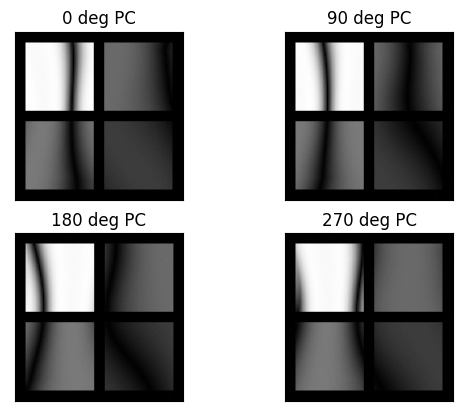

(160, 128, 128, 2) (160, 128, 128, 2)


TypeError: visualize_images() got an unexpected keyword argument 'do_fft'

In [3]:
#dataset = mssfp.generate_ssfp_dataset(phantom_type='block', slices=100, shape=128, npcs=4, f=500, alpha=np.deg2rad(60), sigma=0.001, data_indices=[(0, 2), (120,180)], useRotate=True, useDeform=True)
slices = 200
alphas = np.random.uniform(60, 60, size=slices)
alphas = np.deg2rad(alphas)
alphas = alphas[:, np.newaxis, np.newaxis]
dataset = mssfp.generate_ssfp_dataset(phantom_type='block', slices=slices, shape=128, ids=[1, 2, 3, 4],
                                      npcs=4, f=500, alpha=alphas, sigma=0.001, data_indices=[(0, 2), (120,180)], 
                                      fn_offset=100, rotation=15, useRotate=True, useDeform=True)
data = dataset['M']
data.shape
mssfp.plot_dataset(data, slice=0)
ds = deepssfp.dataset.Dataset(mode, input_data=data)
print(ds.x_train.shape, ds.y_train.shape)

deepssfp.visualize_images(
    input_images=ds.x_test,
    target_images=ds.y_test,
    num_samples=1,
    do_fft = True
)

In [5]:
# Basic training
model, history, ds, predictions = deepssfp.train(
    mode=mode,
    model_name=model_name,
    model_dir=model_dir,
    custom_dataset=ds,
    epochs=400,
    use_early_stopping=False,
    patience=200,
    continue_training=False
)

2025-03-19 21:38:58,508 - DeepSSFP - INFO - Model will be saved to: D:/DeepSSFP/block_phantom_superfov
2025-03-19 21:38:58,508 - DeepSSFP - INFO - Training DataSet: (160, 128, 128, 2) | (160, 128, 128, 2)
2025-03-19 21:38:58,509 - DeepSSFP - INFO - Test DataSet: (40, 128, 128, 2) | (40, 128, 128, 2)
2025-03-19 21:38:59,038 - DeepSSFP - INFO - Creating new model with dimensions: 128x128x2→2


Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 128, 128, 2) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 128, 128, 32) 608         img[0][0]                        
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 128, 128, 32) 9248        conv2d[0][0]                     
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 128, 128, 32) 128         conv2d_1[0][0]                   
______________________________________________________________________________________________

2025-03-19 21:39:05,813 - tensorflow - WARNING - Callback method `on_train_batch_end` is slow compared to the batch time (batch time: 0.0212s vs `on_train_batch_end` time: 0.1273s). Check your callbacks.


20/20 - 8s - loss: 0.7129 - mean_absolute_error: 0.1730 - val_loss: 0.4802 - val_mean_absolute_error: 0.1504

Epoch 00001: val_loss improved from inf to 0.48022, saving model to D:/DeepSSFP\block_phantom_superfov.keras
Epoch 2/400
20/20 - 1s - loss: 0.1320 - mean_absolute_error: 0.0849 - val_loss: 0.1760 - val_mean_absolute_error: 0.0867

Epoch 00002: val_loss improved from 0.48022 to 0.17605, saving model to D:/DeepSSFP\block_phantom_superfov.keras
Epoch 3/400
20/20 - 1s - loss: 0.0884 - mean_absolute_error: 0.0740 - val_loss: 0.1106 - val_mean_absolute_error: 0.0760

Epoch 00003: val_loss improved from 0.17605 to 0.11064, saving model to D:/DeepSSFP\block_phantom_superfov.keras
Epoch 4/400
20/20 - 1s - loss: 0.0701 - mean_absolute_error: 0.0689 - val_loss: 0.0868 - val_mean_absolute_error: 0.0708

Epoch 00004: val_loss improved from 0.11064 to 0.08678, saving model to D:/DeepSSFP\block_phantom_superfov.keras
Epoch 5/400
20/20 - 1s - loss: 0.0588 - mean_absolute_error: 0.0655 - val_lo

2025-03-19 21:52:43,037 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/block_phantom_superfov.keras


2/2 [==============================] - 1s 10ms/step - loss: 0.0194 - mean_absolute_error: 0.0266


2025-03-19 21:52:44,445 - DeepSSFP - INFO - Training Complete. Loss: 0.0194, MAE: 0.0266
2025-03-19 21:52:44,445 - DeepSSFP - INFO - Time Elapsed: 824.53 seconds


2025-03-20 18:30:47,724 - DeepSSFP - INFO - Loading model from path: D:/DeepSSFP/block_phantom_superfov
2025-03-20 18:31:13,935 - DeepSSFP - INFO - Model loaded successfully from D:/DeepSSFP/block_phantom_superfov.keras
2025-03-20 18:31:13,936 - DeepSSFP - INFO - Loading training history from D:/DeepSSFP/block_phantom_superfov_history.npz
2025-03-20 18:31:15,042 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/block_phantom_superfov_training_history.png


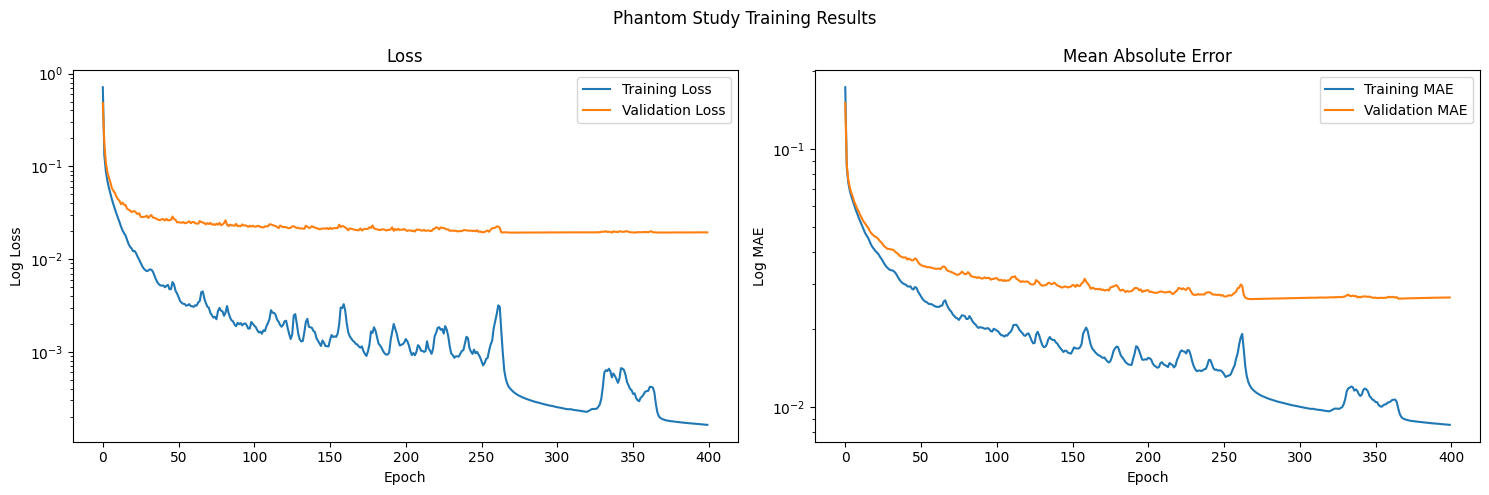

In [6]:
model, history_dict = deepssfp.load_model(
    mode=mode,
    model_name=model_name,
    model_dir=model_dir
)

deepssfp.plot_training_history(
    history_dict,
    title="Phantom Study Training Results",
    save_path=f"{path}_training_history.png"
)

2025-03-20 18:32:05,085 - DeepSSFP - INFO - Making predictions on data with shape (40, 128, 128, 2)
2025-03-20 18:32:05,485 - DeepSSFP - INFO - Predictions complete. Output shape: (40, 128, 128, 2)


Selected indices: [10 33]
Figure size: (6, 4)
Image visualization saved to D:/DeepSSFP/block_phantom_superfov_prediction_results.png


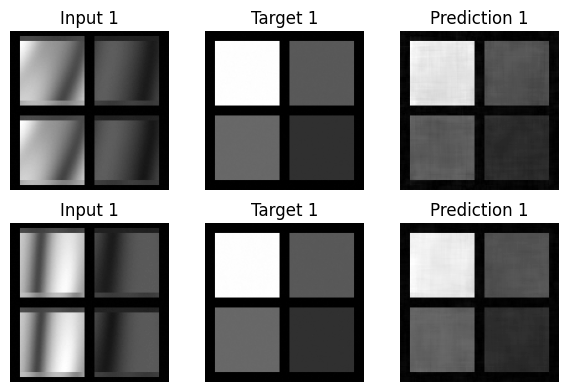

In [8]:
ds = deepssfp.Dataset(mode, input_data=data)

predictions = deepssfp.predict(model, ds.x_test)

deepssfp.visualize_images(
    input_images=ds.x_test,
    target_images=ds.y_test,
    predicted_images=predictions,
    num_samples=2,
    kspace = True,
    save_path=f"{path}_prediction_results.png"
)

(40, 128, 128) (40, 128, 128)
Target shape: (40, 128, 128)
Prediction shape: (40, 128, 128)
Segmentation shape: (128, 128)
Unique segmentation IDs: [0. 1. 2. 3. 4.]
IDs to plot: [1. 2. 3. 4.]
Training history plot saved to D:/DeepSSFP/block_phantom_superfov_metrics_scatter


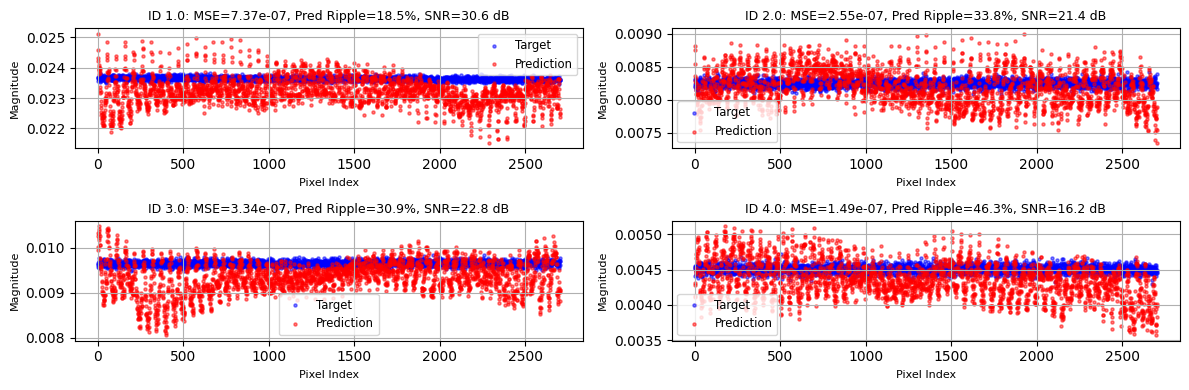

Training history plot saved to D:/DeepSSFP/block_phantom_superfov_metrics


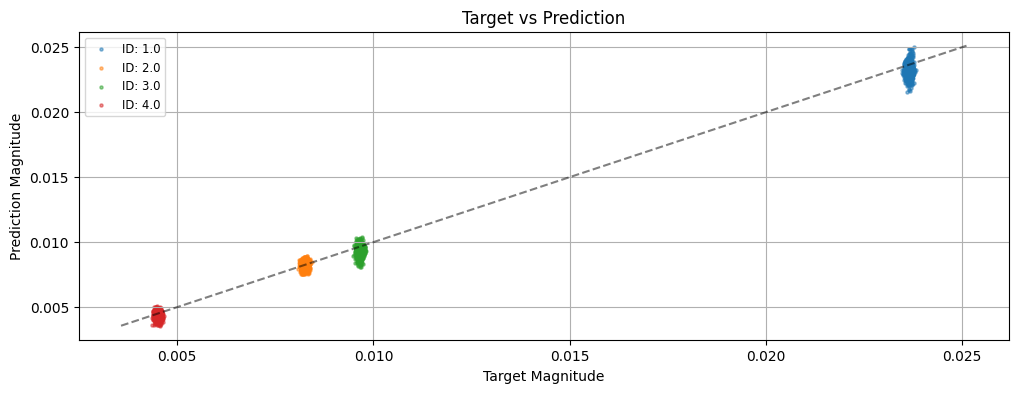


Metrics by Segment ID (averaged across all samples):
ID 1.0: MSE=7.37e-07, MAE=6.53e-04, Pred Min=0.0214, Pred Max=0.0258, Pred Ripple=18.46%, Pred SNR=30.6 dB, Target Min=0.0234, Target Max=0.0238, Target Ripple=1.65%, Target SNR=50.4 dB, Samples=40, Pixels=2704
ID 2.0: MSE=2.55e-07, MAE=3.90e-04, Pred Min=0.0067, Pred Max=0.0095, Pred Ripple=33.84%, Pred SNR=21.4 dB, Target Min=0.0081, Target Max=0.0084, Target Ripple=4.41%, Target SNR=41.3 dB, Samples=40, Pixels=2704
ID 3.0: MSE=3.34e-07, MAE=4.39e-04, Pred Min=0.0080, Pred Max=0.0110, Pred Ripple=30.87%, Pred SNR=22.8 dB, Target Min=0.0095, Target Max=0.0098, Target Ripple=3.70%, Target SNR=42.7 dB, Samples=40, Pixels=2704
ID 4.0: MSE=1.49e-07, MAE=3.02e-04, Pred Min=0.0034, Pred Max=0.0055, Pred Ripple=46.34%, Pred SNR=16.2 dB, Target Min=0.0043, Target Max=0.0047, Target Ripple=7.87%, Target SNR=36.0 dB, Samples=40, Pixels=2704
{1.0: {'mse': 7.365794627316516e-07, 'mae': 0.0006533591516413825, 'pred_min': 0.021442527582278267, '

In [ ]:
pred = deepssfp.ifft(deepssfp.from_pairs_to_complex(predictions))
target = deepssfp.ifft(deepssfp.from_pairs_to_complex(ds.y_test))
print(target.shape, pred.shape)

metrics = deepssfp.evaluate_band_reduction(target, pred, dataset['seg'], sort_values=False, fig_size=(6, 2), save_path=f"{path}_metrics")
print(metrics)